**Objective: Clinical Text Preprocessing, Report Parsing, and Audit-Ready Dataset Construction**

The objective of this notebook is to extract, clean, standardize, and audit unstructured clinical narratives from MIMIC-CXR radiology reports for downstream Explainable Medical LLM development. The pipeline focuses on linking free-text chest radiology reports from `mimic-cxr-reports.zip` to the validated multimodal cohort produced in Notebook 01 through the shared `study_id` identifier.

The notebook isolates clinically meaningful report sections, especially `FINDINGS` and `IMPRESSION`, removes unusable or empty narrative records, constructs a unified `clinical_text` field, and exports a text-integrated cohort suitable for later instruction generation, reasoning dataset construction, retrieval preparation, and leakage-safe model development.

**Pipeline Scope**  
◽ Load and validate the foundational cohort from `cohort_merged.csv`  
◽ Stream relevant radiology reports directly from the compressed `.zip` archive without full extraction  
◽ Parse raw reports using robust section-detection logic for `FINDINGS` and `IMPRESSION`  
◽ Merge extracted clinical text with the multimodal cohort using `study_id`  
◽ Quantify merge coverage, missing reports, empty-section records, and text-quality statistics  
◽ Perform leakage and split-readiness checks before downstream modeling  
◽ Export the integrated dataset and reproducible audit artifacts  
◽ Prepare optional clinical NLP enhancement artifacts, including cue profiling, term normalization, Chain-of-Evidence draft packaging, prompt-contract normalization, and retrieval-ready text chunks  

**Technical and Clinical Significance**  
◽ **Technical:**  
This notebook converts raw semi-structured clinical text into a validated, reproducible, and audit-ready dataset. Direct archive streaming reduces disk usage and avoids unnecessary decompression, while explicit merge-loss auditing prevents silent data loss. Text-quality diagnostics, leakage-readiness checks, and persistent audit files establish a reliable preprocessing checkpoint for downstream LLM training and evaluation.

◽ **Clinical:**  
Radiology reports contain both diagnostic evidence and administrative noise. By focusing on `FINDINGS` and `IMPRESSION`, the pipeline preserves the parts of the report most relevant to clinical reasoning: objective imaging observations and the radiologist’s diagnostic synthesis. This supports the development of explainable models that learn from evidence-based clinical narratives rather than unstructured or potentially misleading report metadata.

**Expected Main Output**  
The main output of this notebook is the text-integrated cohort file: `cohort_text_integrated.csv` 

This file serves as the validated clinical-text foundation for later notebooks involving instruction tuning, Chain-of-Evidence generation, retrieval-augmented generation, and explainability-focused evaluation.

**Preliminary Setup: Library Import, Hardware Verification, and Shared Pipeline Utilities**

This preliminary setup prepares the notebook environment before clinical text extraction begins. It imports the required Python libraries, registers the project root for local module access, applies a consistent academic plotting style, verifies the available computation hardware, and defines shared utility functions used by the optional enhancement stages later in the pipeline.

In [1]:
# Imported Libraries (categorized)

# ---------------------------------------------------------
# Standard Library
# ---------------------------------------------------------
import sys
import os

# Add project root to sys.path to resolve 'src' imports
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# ---------------------------------------------------------
# Data Handling and Manipulation Libraries
# ---------------------------------------------------------
import re
import json
import zipfile
from pathlib import Path
from collections import Counter

# ---------------------------------------------------------
# Core Data and Visualization
# ---------------------------------------------------------
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# Project Utilities
# ---------------------------------------------------------
from src.utils.hardware_verification import verify_hardware

# Global Plot Style Configuration
mpl.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   12.5,
    "axes.titleweight": "normal",
    "axes.labelsize":   11.5,
    "axes.labelweight": "normal",
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
    "legend.fontsize":  10,
    "figure.dpi":       100,
})

print("Libraries imported and academic plotting style successfully applied.")

# Global Device Configuration for PyTorch
device = verify_hardware()
print(f"Global Computation Device Set To: {device}")


Libraries imported and academic plotting style successfully applied.
⏳ Initializing hardware verification protocol...

🖥️ OS: Windows 11 | CPU: Intel64 Family 6 Model 151 Stepping 2, GenuineIntel | RAM: 31.7 GB

✅ GPU Accelerator detected successfully.
🎮 Hardware Device: NVIDIA GeForce RTX 3090
💾 Total VRAM Allocated: 24.00 GB
🚀 System is fully optimized and ready for heavy tensor operations.

🔧 PyTorch Version: 2.6.0+cu124
✅ PyTorch CUDA is available.
   Device Name : NVIDIA GeForce RTX 3090
   CUDA Version: 12.4
   cuDNN Version: 90100
   VRAM (PyTorch): 24.00 GB
   Selected Device: cuda
Global Computation Device Set To: cuda


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Pipeline Utility Functions — used by Steps 6–10
# resolve_pipeline_dataframe() : resolves the primary clinical text DataFrame
# resolve_text_column()        : identifies the correct text column to use
# ─────────────────────────────────────────────────────────────────────────────

def resolve_pipeline_dataframe(step_label: str = "Unknown Step") -> tuple:
    """
    Resolves the primary clinical text DataFrame for optional enhancement steps.

    Resolution order:
      1. df_integrated  — preferred: fully validated output of Step 5
      2. Live session globals — fallback if Step 5 output is not in scope
      3. CSV file fallback — last resort from OUTPUTS_DIR / BASE_DIR

    Returns : (text_df, source_name)
    Raises  : RuntimeError if no valid DataFrame is found.
    """
    # 1. Preferred: output of Step 5
    if "df_integrated" in globals() and isinstance(globals()["df_integrated"], pd.DataFrame):
        if len(globals()["df_integrated"]) > 0:
            return globals()["df_integrated"].copy(), "df_integrated"

    # 2. Live globals fallback
    for var_name in ["df_text", "df_notes", "df_text_processed", "df_clinical_text", "df"]:
        obj = globals().get(var_name)
        if isinstance(obj, pd.DataFrame) and len(obj) > 0:
            return obj.copy(), var_name

    # 3. CSV file fallback
    base = globals().get("BASE_DIR", Path.cwd())
    out  = globals().get("OUTPUTS_DIR", base / "outputs")
    for p in [out / "cohort_text_integrated.csv",       # Step 5 output — correct source
             base / "cohort_text_integrated.csv",      # fallback if OUTPUTS_DIR differs
             out / "multimodal_master_cohort.csv",
             base / "multimodal_master_cohort.csv",
             base / "cohort_final_selected_hadm_repaired.csv"]:
        if p.exists():
            try:
                df = pd.read_csv(p)
                if len(df) > 0:
                    return df, str(p)
            except Exception:
                continue

    raise RuntimeError(
        f"[{step_label}] No valid clinical text DataFrame found. "
        "Run Steps 1–5 first, or verify CSV fallback paths."
    )


def resolve_text_column(df: pd.DataFrame, concat_col_name: str = "resolved_text") -> str:
    """
    Finds the primary text column in a clinical DataFrame.
    If 'findings' + 'impression' both exist but no unified column,
    auto-creates a merged column named concat_col_name.

    Returns : column name (str)
    Raises  : KeyError if no usable text column is found.
    """
    for col in ["clinical_text", "text", "report_text"]:
        if col in df.columns:
            return col
    if {"findings", "impression"}.issubset(df.columns):
        df[concat_col_name] = (
            df["findings"].fillna("").astype(str)
            + " "
            + df["impression"].fillna("").astype(str)
        ).str.strip()
        return concat_col_name
    obj_cols = [c for c in df.columns if df[c].dtype == object]
    if obj_cols:
        return obj_cols[0]
    raise KeyError(
        f"Cannot locate a usable text column. Available: {list(df.columns)}"
    )


print("✅ Pipeline utilities registered: resolve_pipeline_dataframe() | resolve_text_column()")


✅ Pipeline utilities registered: resolve_pipeline_dataframe() | resolve_text_column()


**Step 1: Environment Initialization and Cohort Loading**

This step prepares the local preprocessing environment and loads the validated multimodal cohort from Notebook 01. The required dataset paths are defined, output folders are created, and the availability of the main cohort file and MIMIC-CXR report archive is checked before any text extraction begins.

**Main Operations**  
◽ Define the base dataset directory and required file paths  
◽ Create output folders for processed files and quality-control reports  
◽ Validate the presence of `cohort_merged.csv` and `mimic-cxr-reports.zip`  
◽ Load the foundational cohort into `df_cohort`  
◽ Check that `study_id` exists and convert it into a stable numeric identifier  
◽ Remove records with missing or invalid `study_id` values  
◽ Initialize the first audit statistics in `text_pipeline_audit`

**Technical and Clinical Significance**  
This step ensures that the cohort is ready for reliable linkage with radiology reports. Since `study_id` is the key used to match cohort rows with MIMIC-CXR text files, validating and standardizing this identifier prevents silent linkage errors and protects the integrity of the downstream clinical text dataset.

**Expected Outcome**  
A validated `df_cohort` dataframe is available with usable `study_id` values, required input files are checked, output directories are ready, and the initial audit information is stored for later quality-control reporting.

In [3]:
# Step 1: Environment setup, path validation, and loading the foundational cohort

print("Initializing base directory for local Windows environment...")

# ---------------------------------------------------------
# 0) Base Directory Configuration
# ---------------------------------------------------------
BASE_DIR = Path.home() / "OneDrive - hull.ac.uk" / "Explainable Medical LLM Dataset" / "datasets"
print(f"Base directory: {BASE_DIR}")

# ---------------------------------------------------------
# 1) Output Directories Setup
# ---------------------------------------------------------
QUALITY_DIR = BASE_DIR / "quality_reports"
OUTPUTS_DIR  = BASE_DIR / "outputs"
QUALITY_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Quality reports directory : {QUALITY_DIR}")
print(f"Outputs directory         : {OUTPUTS_DIR}")

# ---------------------------------------------------------
# 2) File Path Validation and Cohort Loading
# ---------------------------------------------------------
PATH_MASTER_COHORT = BASE_DIR / "cohort_merged.csv"
PATH_CXR_REPORTS_ZIP = BASE_DIR / "mimic_cxr" / "mimic-cxr-reports.zip"

print("\n--- File Verification Status ---")
for file_path in [PATH_MASTER_COHORT, PATH_CXR_REPORTS_ZIP]:
    if file_path.exists():
        print(f"File validated: {file_path.name}")
    else:
        print(f"Warning - file not found: {file_path}")

if not PATH_MASTER_COHORT.exists():
    raise FileNotFoundError("cohort_merged.csv is missing. Re-run Notebook 1.")

print("\nLoading the foundational multimodal cohort...")
df_cohort = pd.read_csv(PATH_MASTER_COHORT)
print(f"Loaded rows: {len(df_cohort):,}")

if "study_id" not in df_cohort.columns:
    raise KeyError("Column 'study_id' is required in cohort_merged.csv for text linkage.")

# Canonical study_id casting for stable archive matching.
df_cohort["study_id"] = pd.to_numeric(df_cohort["study_id"], errors="coerce")
rows_before_studyid_filter = int(len(df_cohort))
missing_studyid_rows = int(df_cohort["study_id"].isna().sum())

df_cohort = df_cohort.dropna(subset=["study_id"]).copy()
df_cohort["study_id"] = df_cohort["study_id"].astype(int)

print(f"Rows after study_id validation: {len(df_cohort):,}")
print(f"Rows removed due to missing/invalid study_id: {missing_studyid_rows:,}")
if "subject_id" in df_cohort.columns:
    print(f"Unique patients pending text extraction: {df_cohort['subject_id'].nunique():,}")

# Session-level audit seed.
text_pipeline_audit = {
    "cohort_rows_loaded": rows_before_studyid_filter,
    "cohort_rows_missing_study_id": missing_studyid_rows,
    "cohort_rows_after_study_id_filter": int(len(df_cohort)),
}


Initializing base directory for local Windows environment...
Base directory: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets
Quality reports directory : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports
Outputs directory         : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs

--- File Verification Status ---
File validated: cohort_merged.csv
File validated: mimic-cxr-reports.zip

Loading the foundational multimodal cohort...
Loaded rows: 89,747
Rows after study_id validation: 89,747
Rows removed due to missing/invalid study_id: 0
Unique patients pending text extraction: 52,766


**Step 2: Targeted Report Extraction from the Compressed Archive**

This step extracts only the radiology reports required for the validated cohort directly from `mimic-cxr-reports.zip`. Instead of decompressing the full archive, the code scans the `.txt` report files, identifies reports by their `study_id`, and loads only the matching reports into memory.

**Main Operations**  
◽ Build the target list of required `study_id` values from `df_cohort`  
◽ Open the MIMIC-CXR reports archive without full extraction  
◽ Scan available `.txt` report files inside the archive  
◽ Parse report filenames to identify matching study-level reports  
◽ Load only reports linked to the cohort study IDs  
◽ Apply decoding fallbacks when UTF-8 decoding is not sufficient  
◽ Track missing reports, skipped files, and decoding issues in the audit object  

**Technical and Clinical Significance**  
This targeted extraction strategy improves efficiency and reduces storage overhead by avoiding full archive decompression. It also provides an explicit audit of which cohort studies have matching reports, which files were skipped, and whether any text-decoding fallback was required. Clinically, this protects the traceability between each imaging study in the cohort and its original radiology narrative.

**Expected Outcome**  
The required raw radiology reports are loaded into `raw_reports_dict`, missing report IDs are identified, and extraction statistics are added to `text_pipeline_audit` for downstream quality control.

In [4]:
# Step 2: Direct in-memory extraction of relevant radiology reports

print("Initializing targeted report extraction...")

if "df_cohort" not in globals():
    raise RuntimeError("df_cohort not found. Run Step 1 first.")
if not PATH_CXR_REPORTS_ZIP.exists():
    raise FileNotFoundError(f"Reports archive not found: {PATH_CXR_REPORTS_ZIP}")

required_study_ids = set(df_cohort["study_id"].dropna().astype(int).astype(str))
print(f"Target identified: {len(required_study_ids):,} unique studies required.")

raw_reports_dict = {}
matched_study_ids = set()
skipped_non_report_files = 0
skipped_unparsable_filenames = 0
decode_fallback_latin1 = 0
decode_replace_used = 0

with zipfile.ZipFile(PATH_CXR_REPORTS_ZIP, "r") as archive:
    all_files = archive.namelist()
    txt_files = [f for f in all_files if f.lower().endswith(".txt")]
    print(f"Total report files detected in archive: {len(txt_files):,}")
    print("Scanning and extracting matching reports...")

    for file_path in txt_files:
        filename = file_path.split("/")[-1]
        match = re.search(r"^s(\d+)\.txt$", filename, flags=re.IGNORECASE)
        if not match:
            skipped_unparsable_filenames += 1
            continue

        study_id_str = match.group(1)
        if study_id_str not in required_study_ids:
            skipped_non_report_files += 1
            continue

        with archive.open(file_path) as file:
            raw_bytes = file.read()

        try:
            content = raw_bytes.decode("utf-8")
        except UnicodeDecodeError:
            try:
                content = raw_bytes.decode("latin-1")
                decode_fallback_latin1 += 1
            except Exception:
                content = raw_bytes.decode("utf-8", errors="replace")
                decode_replace_used += 1

        raw_reports_dict[int(study_id_str)] = content
        matched_study_ids.add(study_id_str)

missing_report_ids = sorted(int(x) for x in (required_study_ids - matched_study_ids))

print("Extraction completed.")
print(f"Reports loaded into memory: {len(raw_reports_dict):,}")
print(f"Required IDs missing in archive: {len(missing_report_ids):,}")
print(f"Decode fallback (latin-1): {decode_fallback_latin1:,}")
print(f"Decode fallback (replace): {decode_replace_used:,}")

text_pipeline_audit.update({
    "required_study_ids": int(len(required_study_ids)),
    "reports_extracted": int(len(raw_reports_dict)),
    "required_ids_missing_in_archive": int(len(missing_report_ids)),
    "filename_parse_skips": int(skipped_unparsable_filenames),
    "non_required_txt_skips": int(skipped_non_report_files),
    "decode_fallback_latin1": int(decode_fallback_latin1),
    "decode_fallback_replace": int(decode_replace_used),
})


Initializing targeted report extraction...
Target identified: 89,291 unique studies required.
Total report files detected in archive: 227,835
Scanning and extracting matching reports...
Extraction completed.
Reports loaded into memory: 89,291
Required IDs missing in archive: 0
Decode fallback (latin-1): 0
Decode fallback (replace): 0


**Step 3: Clinical Narrative Parsing and Section Extraction**

This step converts raw radiology report text into structured clinical sections. The parser focuses on extracting the `FINDINGS` and `IMPRESSION` sections because these parts contain the main imaging observations and the radiologist’s diagnostic interpretation.

**Main Operations**  
◽ Convert extracted raw reports into a report-level dataframe  
◽ Standardize `study_id` for reliable downstream merging  
◽ Normalize report text spacing and formatting  
◽ Extract `FINDINGS` and `IMPRESSION` using regex-based section detection  
◽ Apply fallback header-based parsing when direct regex extraction is not sufficient  
◽ Record the extraction source for each section as `regex`, `header_map`, or `missing`  
◽ Summarize section availability and parser-source coverage  

**Technical and Clinical Significance**  
This step reduces unstructured report noise and keeps the clinically meaningful narrative sections needed for downstream modeling. Tracking the extraction source makes the parsing process auditable and helps identify reports where section structure is incomplete or non-standard.

**Expected Outcome**  
A structured `df_reports` dataframe is created with `study_id`, raw report text, extracted `findings`, extracted `impression`, and parser-source indicators for quality control.

In [5]:
# Step 3: Regex-based extraction of key clinical sections from raw reports

print("Initializing regex parsing for clinical narratives...")

if "raw_reports_dict" not in globals():
    raise RuntimeError("raw_reports_dict not found. Run extraction step first.")

def normalize_text_block(value):
    if value is None:
        return None
    value = re.sub(r"\s+", " ", value).strip()
    return value if value else None

def extract_first_match(text, patterns):
    for pattern in patterns:
        match = re.search(pattern, text, flags=re.IGNORECASE | re.DOTALL | re.MULTILINE)
        if match:
            return normalize_text_block(match.group(1))
    return None

def parse_sections_by_headers(text):
    # Fallback parser for reports that use uncommon section ordering or labels.
    matches = list(re.finditer(r"^\s*([A-Z][A-Z\s/\-]{2,})\s*:\s*", text, flags=re.MULTILINE))
    if not matches:
        return {}

    sections = {}
    for idx, match in enumerate(matches):
        header = re.sub(r"\s+", " ", match.group(1)).strip().upper()
        section_start = match.end()
        section_end = matches[idx + 1].start() if idx + 1 < len(matches) else len(text)
        section_text = normalize_text_block(text[section_start:section_end])
        if section_text:
            sections[header] = section_text
    return sections

def pick_from_aliases(section_map, aliases):
    for alias in aliases:
        if alias in section_map and section_map[alias]:
            return section_map[alias], f"header_map_{alias.lower()}"
    return None, None

def extract_clinical_sections(text):
    """
    Parse raw report text and extract FINDINGS and IMPRESSION sections.
    Supports minor header-format variability and fallback header mapping.
    """
    if not isinstance(text, str) or not text.strip():
        return None, None, "missing", "missing"

    section_end = r"(?=^\s*[A-Z][A-Z\s/\-]{2,}:|^\s*FINAL REPORT\b|\Z)"

    findings_patterns = [
        rf"^\s*FINDINGS\s*:\s*(.*?){section_end}",
        rf"^\s*FINDING\s*:\s*(.*?){section_end}",
    ]
    impression_patterns = [
        rf"^\s*IMPRESSION\s*:\s*(.*?){section_end}",
        rf"^\s*CONCLUSION\s*:\s*(.*?){section_end}",
    ]

    findings = extract_first_match(text, findings_patterns)
    impression = extract_first_match(text, impression_patterns)

    findings_source = "regex" if findings else None
    impression_source = "regex" if impression else None

    if findings is None or impression is None:
        section_map = parse_sections_by_headers(text)

        if findings is None:
            findings, findings_source = pick_from_aliases(section_map, ["FINDINGS", "FINDING"])

        if impression is None:
            impression, impression_source = pick_from_aliases(
                section_map,
                ["IMPRESSION", "CONCLUSION", "OPINION", "ASSESSMENT"],
            )

    findings_source = findings_source or "missing"
    impression_source = impression_source or "missing"

    return findings, impression, findings_source, impression_source

def normalize_audit_key(value):
    return re.sub(r"[^a-z0-9]+", "_", str(value).lower()).strip("_")

df_reports = pd.DataFrame(list(raw_reports_dict.items()), columns=["study_id", "raw_text"])
df_reports["study_id"] = pd.to_numeric(df_reports["study_id"], errors="coerce").astype("Int64")
df_reports = df_reports.dropna(subset=["study_id"]).copy()
df_reports["study_id"] = df_reports["study_id"].astype(int)

print(f"Processing {len(df_reports):,} raw reports...")

if len(df_reports) == 0:
    raise RuntimeError("No reports available for parsing. Check extraction and archive coverage.")

df_reports[["findings", "impression", "findings_source", "impression_source"]] = df_reports["raw_text"].apply(
    lambda x: pd.Series(extract_clinical_sections(x))
)

findings_count = int(df_reports["findings"].notna().sum())
impression_count = int(df_reports["impression"].notna().sum())
parsed_any_text_count = int(((df_reports["findings"].notna()) | (df_reports["impression"].notna())).sum())

denom = max(len(df_reports), 1)
print("\nText parsing completed.")
print("Extraction statistics:")
print(f"- Reports with FINDINGS: {findings_count:,} ({(findings_count / denom) * 100:.1f}%)")
print(f"- Reports with IMPRESSION: {impression_count:,} ({(impression_count / denom) * 100:.1f}%)")
print(f"- Reports with any usable section: {parsed_any_text_count:,} ({(parsed_any_text_count / denom) * 100:.1f}%)")

findings_source_counts = df_reports["findings_source"].value_counts(dropna=False)
impression_source_counts = df_reports["impression_source"].value_counts(dropna=False)

df_parser_source_summary = pd.concat(
    [
        findings_source_counts.rename("findings_count"),
        impression_source_counts.rename("impression_count"),
    ],
    axis=1,
).fillna(0).astype(int)
df_parser_source_summary = df_parser_source_summary.rename_axis("source").reset_index()

print("\nSection source summary:")
display(df_parser_source_summary)
display(df_reports[["study_id", "findings", "impression", "findings_source", "impression_source"]].head())

text_pipeline_audit.update({
    "reports_parsed": int(len(df_reports)),
    "reports_with_findings": findings_count,
    "reports_with_impression": impression_count,
    "reports_with_any_section": parsed_any_text_count,
})

for source, count in findings_source_counts.items():
    text_pipeline_audit[f"findings_source_{normalize_audit_key(source)}"] = int(count)
for source, count in impression_source_counts.items():
    text_pipeline_audit[f"impression_source_{normalize_audit_key(source)}"] = int(count)


Initializing regex parsing for clinical narratives...
Processing 89,291 raw reports...

Text parsing completed.
Extraction statistics:
- Reports with FINDINGS: 80,055 (89.7%)
- Reports with IMPRESSION: 84,564 (94.7%)
- Reports with any usable section: 88,120 (98.7%)

Section source summary:


,source,findings_count,impression_count
0,regex,80055,84563
1,missing,9236,4727
2,header_map_opinion,0,1


,study_id,findings,impression,findings_source,impression_source
0,58832226,The heart is normal in size. The mediastinal a...,No evidence of acute disease.,regex,regex
1,52876267,Frontal and lateral views of the chest were ob...,Slight pulmonary vascular congestion without p...,regex,regex
2,55630025,Single semi-erect AP portable view of the ches...,None,regex,missing
3,50334688,The cardiac silhouette and pulmonary vasculatu...,No definite mass identified. Bibasilar opaciti...,regex,regex
4,50770286,Endotracheal tube tip terminates 3 cm from the...,1. Satisfactory position of endotracheal and e...,regex,regex


**Step 4.1: Cohort Integration, Merge Audit, and Clinical Text Construction**

This step links the parsed radiology report sections with the validated multimodal cohort using `study_id`. After merging, records without usable clinical narrative content are removed, and a unified `clinical_text` field is constructed from the available `FINDINGS` and `IMPRESSION` sections.

**Main Operations**  
◽ Merge the foundational cohort with parsed report sections using `study_id`  
◽ Preserve unmatched rows for merge-loss auditing  
◽ Measure report-linkage coverage and unmatched cohort records  
◽ Clean empty or missing `findings` and `impression` values  
◽ Remove rows where both extracted sections are empty  
◽ Build the final `clinical_text` field using available report sections  
◽ Update the audit object with merge and text-retention statistics  

**Technical and Clinical Significance**  
This step creates the main text-integrated dataset while preventing silent row loss. The merge audit confirms how many cohort records were successfully linked to radiology reports, and the text-filtering logic ensures that downstream models receive only records with meaningful clinical narrative content.

**Expected Outcome**  
A validated `df_integrated` dataframe is created, containing structured cohort variables together with cleaned report-derived clinical text.

In [6]:
# Step 4.1: Integrating clinical text with the foundational cohort and synthesizing a unified narrative

print("Initiating integration of clinical narratives with the primary cohort...")

if "df_reports" not in globals():
    raise RuntimeError("df_reports not found. Run text parsing step first.")

# Coverage-aware merge to avoid silent row loss.
df_merged = pd.merge(
    df_cohort,
    df_reports,
    on="study_id",
    how="left",
    indicator=True,
)

rows_input = int(len(df_merged))
rows_matched_report = int((df_merged["_merge"] == "both").sum())
rows_unmatched_report = rows_input - rows_matched_report
merge_match_rate_pct = (rows_matched_report / max(rows_input, 1)) * 100.0

print(f"Rows entering merge: {rows_input:,}")
print(f"Rows matched to report: {rows_matched_report:,}")
print(f"Rows unmatched to report: {rows_unmatched_report:,}")
print(f"Merge match rate: {merge_match_rate_pct:.2f}%")

# Keep unmatched linkage rows for audit export.
audit_link_cols = [c for c in ["subject_id", "stay_id", "study_id"] if c in df_merged.columns]
df_unmatched_cohort_rows = df_merged.loc[df_merged["_merge"] != "both", audit_link_cols].copy()

# Normalize text fields before quality filtering.
for col in ["findings", "impression"]:
    if col not in df_merged.columns:
        df_merged[col] = ""
    df_merged[col] = (
        df_merged[col]
        .fillna("")
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

valid_text_mask = (df_merged["findings"].str.len() > 0) | (df_merged["impression"].str.len() > 0)
df_integrated = df_merged.loc[valid_text_mask].copy()

rows_after_text_filter = int(len(df_integrated))
rows_removed_no_text = rows_matched_report - rows_after_text_filter

# Construct a unified narrative field for downstream LLM ingestion.
def synthesize_report(row):
    parts = []
    if row["findings"]:
        parts.append(f"FINDINGS: {row['findings']}")
    if row["impression"]:
        parts.append(f"IMPRESSION: {row['impression']}")
    return " | ".join(parts)

df_integrated["clinical_text"] = df_integrated.apply(synthesize_report, axis=1)

# Drop merge indicator from final export artifact.
if "_merge" in df_integrated.columns:
    df_integrated = df_integrated.drop(columns=["_merge"])

print("\nData integration and semantic cleaning completed.")
print(f"Final validated dataset size: {len(df_integrated):,}")
print(f"Rows removed due to empty findings+impression: {rows_removed_no_text:,}")

if "label_mortality_observed" in df_integrated.columns:
    mortality_count = int((pd.to_numeric(df_integrated["label_mortality_observed"], errors="coerce") == 1).sum())
elif "hospital_expire_flag" in df_integrated.columns:
    mortality_count = int(pd.to_numeric(df_integrated["hospital_expire_flag"], errors="coerce").fillna(0).sum())
else:
    mortality_count = -1

if mortality_count >= 0:
    print(f"Maintained mortality cases: {mortality_count:,}")

preview_cols = [c for c in ["subject_id", "study_id", "clinical_text", "hospital_expire_flag", "label_mortality_observed"] if c in df_integrated.columns]
display(df_integrated[preview_cols].head())

text_pipeline_audit.update({
    "merge_rows_input": rows_input,
    "merge_rows_matched_report": rows_matched_report,
    "merge_rows_unmatched_report": rows_unmatched_report,
    "merge_match_rate_pct": round(merge_match_rate_pct, 4),
    "rows_after_text_quality_filter": rows_after_text_filter,
    "rows_removed_no_findings_and_impression": int(max(rows_removed_no_text, 0)),
    "final_rows_text_integrated": int(len(df_integrated)),
})


Initiating integration of clinical narratives with the primary cohort...
Rows entering merge: 89,747
Rows matched to report: 89,747
Rows unmatched to report: 0
Merge match rate: 100.00%

Data integration and semantic cleaning completed.
Final validated dataset size: 88,570
Rows removed due to empty findings+impression: 1,177
Maintained mortality cases: 2,270


,subject_id,study_id,clinical_text,hospital_expire_flag,label_mortality_observed
0,10000032,53911762,FINDINGS: Single frontal view of the chest pro...,0.0,0.0
1,10000032,50414267,"FINDINGS: There is no focal consolidation, ple...",0.0,0.0
2,10000032,56699142,FINDINGS: The lungs are clear of focal consoli...,0.0,0.0
3,10000032,53189527,"FINDINGS: The cardiac, mediastinal and hilar c...",0.0,0.0
4,10000032,53911762,FINDINGS: Single frontal view of the chest pro...,0.0,0.0


**Step 4.2: Text Quality Diagnostics and Audit Artifact Generation**

This step evaluates the quality and completeness of the extracted clinical text after cohort integration. It measures section coverage, text length patterns, and parser-source behavior, then saves diagnostic tables and visual summaries for reproducibility.

**Main Operations**  
◽ Calculate coverage for reports containing both sections, only `FINDINGS`, only `IMPRESSION`, or no usable section  
◽ Compute character-length statistics for `findings`, `impression`, and `clinical_text`  
◽ Estimate token counts for the unified clinical text field  
◽ Generate section-coverage and text-length diagnostic plots  
◽ Export quality-control summaries as CSV files  
◽ Store paths to diagnostic artifacts in the audit dictionary  

**Technical and Clinical Significance**  
Text-length and section-coverage diagnostics help detect abnormal preprocessing behavior, such as unexpectedly short reports, missing sections, or parser failures. These checks are important before using the dataset for instruction tuning, retrieval preparation, or explainability experiments.

**Expected Outcome**  
Quality-control files and plots are saved for section coverage, parser behavior, and clinical text length distribution.

Generating text quality diagnostics and visualization artifacts...

Section coverage summary:


,category,count,percent
0,both_sections,76900,85.685
1,findings_only,3577,3.986
2,impression_only,8093,9.018
3,no_section,1177,1.311



Text length summary:


,metric,count,mean,std,min,25%,50%,75%,90%,95%,max
0,findings_char_len,88570.0,288.201569,158.941583,0.0,196.0,276.0,379.0,489.0,563.0,1586.0
1,impression_char_len,88570.0,93.115987,97.992421,0.0,33.0,48.0,125.0,222.0,292.0,1407.0
2,clinical_text_char_len,88570.0,404.523902,201.178719,16.0,269.0,364.0,508.0,671.0,782.0,2377.0
3,clinical_text_token_est,88570.0,58.053698,30.128365,2.0,38.0,52.0,73.0,98.0,114.0,376.0


C:\Users\927997\AppData\Local\Temp\ipykernel_38528\1980004445.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=section_coverage_summary, x="category", y="count", palette="Set2", ax=axes[0])


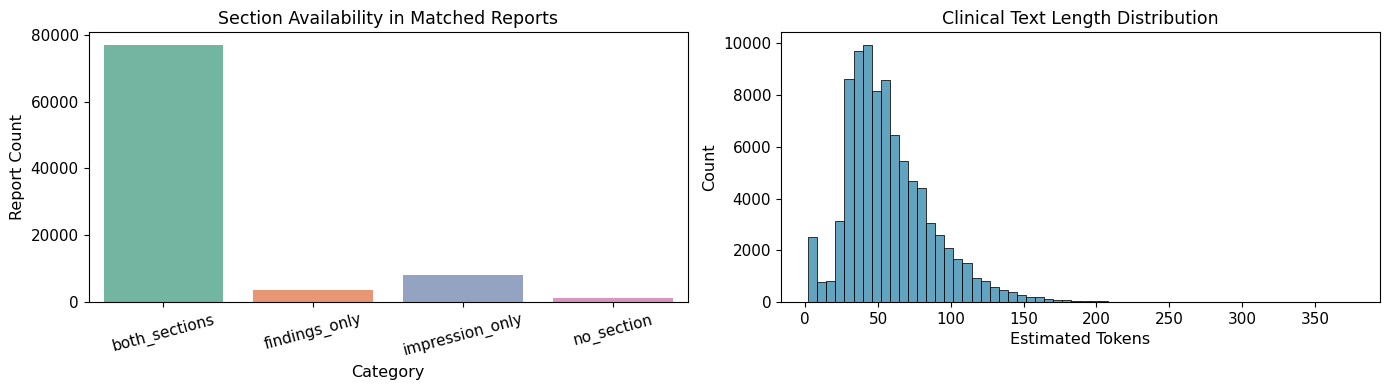

C:\Users\927997\AppData\Local\Temp\ipykernel_38528\1980004445.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=section_coverage_summary, x="category", y="count", palette="Set2")


Diagnostics exported:
- C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\text_section_coverage_summary.csv
- C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\text_length_summary.csv
- C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\text_section_coverage.png
- C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\text_length_distribution.png
- C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\text_parser_source_summary.csv


In [7]:
# Step 4.2:Text quality diagnostics, visualization, and audit artifact generation

print("Generating text quality diagnostics and visualization artifacts...")

required_diag_objects = ["df_reports", "df_merged", "df_integrated"]
missing_diag_objects = [obj for obj in required_diag_objects if obj not in globals()]
if missing_diag_objects:
    raise RuntimeError(f"Missing required objects for text diagnostics: {missing_diag_objects}")

df_matched_reports = df_merged.loc[df_merged["_merge"] == "both"].copy() if "_merge" in df_merged.columns else df_merged.copy()
for col in ["findings", "impression"]:
    if col not in df_matched_reports.columns:
        df_matched_reports[col] = ""
    df_matched_reports[col] = df_matched_reports[col].fillna("").astype(str).str.strip()

total_matched_reports = int(len(df_matched_reports))
findings_nonempty = df_matched_reports["findings"].str.len() > 0
impression_nonempty = df_matched_reports["impression"].str.len() > 0

both_sections = int((findings_nonempty & impression_nonempty).sum())
findings_only = int((findings_nonempty & (~impression_nonempty)).sum())
impression_only = int(((~findings_nonempty) & impression_nonempty).sum())
no_section = int(((~findings_nonempty) & (~impression_nonempty)).sum())

section_coverage_summary = pd.DataFrame(
    [
        {"category": "both_sections", "count": both_sections},
        {"category": "findings_only", "count": findings_only},
        {"category": "impression_only", "count": impression_only},
        {"category": "no_section", "count": no_section},
    ]
)
section_coverage_summary["percent"] = (
    section_coverage_summary["count"] / max(total_matched_reports, 1) * 100.0
).round(3)

df_text_lengths = df_integrated.copy()
for col in ["findings", "impression", "clinical_text"]:
    if col not in df_text_lengths.columns:
        df_text_lengths[col] = ""
    df_text_lengths[col] = df_text_lengths[col].fillna("").astype(str)

df_text_lengths["findings_char_len"] = df_text_lengths["findings"].str.len()
df_text_lengths["impression_char_len"] = df_text_lengths["impression"].str.len()
df_text_lengths["clinical_text_char_len"] = df_text_lengths["clinical_text"].str.len()
df_text_lengths["clinical_text_token_est"] = df_text_lengths["clinical_text"].str.split().str.len()

length_metrics = [
    "findings_char_len",
    "impression_char_len",
    "clinical_text_char_len",
    "clinical_text_token_est",
]
df_text_length_summary = (
    df_text_lengths[length_metrics]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
    .T.reset_index()
    .rename(columns={"index": "metric"})
)

print("\nSection coverage summary:")
display(section_coverage_summary)

print("\nText length summary:")
display(df_text_length_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=section_coverage_summary, x="category", y="count", palette="Set2", ax=axes[0])
axes[0].set_title("Section Availability in Matched Reports")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Report Count")
axes[0].tick_params(axis="x", rotation=15)

sns.histplot(
    data=df_text_lengths,
    x="clinical_text_token_est",
    bins=60,
    color="#2E86AB",
    ax=axes[1],
)
axes[1].set_title("Clinical Text Length Distribution")
axes[1].set_xlabel("Estimated Tokens")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

if "BASE_DIR" in globals():
    quality_dir = BASE_DIR / "quality_reports"
    quality_dir.mkdir(parents=True, exist_ok=True)

    section_summary_path = quality_dir / "text_section_coverage_summary.csv"
    text_length_summary_path = quality_dir / "text_length_summary.csv"
    section_plot_path = quality_dir / "text_section_coverage.png"
    length_plot_path = quality_dir / "text_length_distribution.png"
    parser_source_summary_path = quality_dir / "text_parser_source_summary.csv"

    section_coverage_summary.to_csv(section_summary_path, index=False)
    df_text_length_summary.to_csv(text_length_summary_path, index=False)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=section_coverage_summary, x="category", y="count", palette="Set2")
    plt.title("Section Availability in Matched Reports")
    plt.xlabel("Category")
    plt.ylabel("Report Count")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(section_plot_path, dpi=220, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(10, 4))
    sns.histplot(data=df_text_lengths, x="clinical_text_token_est", bins=60, color="#2E86AB")
    plt.title("Clinical Text Length Distribution")
    plt.xlabel("Estimated Tokens")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(length_plot_path, dpi=220, bbox_inches="tight")
    plt.close()

    if "df_parser_source_summary" in globals():
        df_parser_source_summary.to_csv(parser_source_summary_path, index=False)

    text_pipeline_audit.update(
        {
            "section_coverage_csv": str(section_summary_path),
            "text_length_summary_csv": str(text_length_summary_path),
            "section_coverage_plot": str(section_plot_path),
            "text_length_plot": str(length_plot_path),
        }
    )
    if "df_parser_source_summary" in globals():
        text_pipeline_audit["parser_source_summary_csv"] = str(parser_source_summary_path)

    print("Diagnostics exported:")
    print(f"- {section_summary_path}")
    print(f"- {text_length_summary_path}")
    print(f"- {section_plot_path}")
    print(f"- {length_plot_path}")
    if "df_parser_source_summary" in globals():
        print(f"- {parser_source_summary_path}")


**Step 4.3: Leakage and Split-Readiness Audit**

This step checks whether the integrated dataset is safe to use in later training and evaluation workflows. It does not create train, validation, or test splits; instead, it audits whether patient-level and study-level identifiers are available for leakage-safe splitting.

**Main Operations**  
◽ Check whether `subject_id` and `study_id` are available  
◽ Summarize the number of unique patients and imaging studies  
◽ Detect whether a split column already exists in the dataset  
◽ If a split column exists, verify that patients and studies do not appear across multiple splits  
◽ Record potential leakage risks related to report-derived text columns  
◽ Export a split-readiness and leakage-audit JSON file  

**Technical and Clinical Significance**  
Clinical datasets must be split carefully to avoid patient-level leakage. If the same patient appears in both training and evaluation sets, model performance can be inflated. This audit makes the dataset readiness explicit and warns that report-derived text must not be used as an input feature when the prediction target is directly derived from the same report.

**Expected Outcome**  
A leakage and split-readiness audit file is saved, documenting identifier availability, split-column status, and patient-level or study-level leakage risks.

In [8]:
# Step 4.3: Leakage and split-readiness audit before export

print("Running leakage and split-readiness audit...")

if "df_integrated" not in globals():
    raise RuntimeError("df_integrated not found. Run Step 4.1 before leakage audit.")

if "text_pipeline_audit" not in globals():
    text_pipeline_audit = {}

leakage_audit = {}

# ---------------------------------------------------------
# 1) Required linkage columns
# ---------------------------------------------------------
required_linkage_cols = ["subject_id", "study_id"]
for col in required_linkage_cols:
    leakage_audit[f"has_{col}"] = col in df_integrated.columns

has_subject_id = leakage_audit["has_subject_id"]
has_study_id = leakage_audit["has_study_id"]

if not has_subject_id:
    leakage_audit["patient_level_split_status"] = "failed_missing_subject_id"
    print("WARNING: subject_id is missing. Patient-level split validation cannot be performed.")
else:
    leakage_audit["unique_subject_ids"] = int(df_integrated["subject_id"].nunique())
    leakage_audit["rows_per_subject_mean"] = round(
        float(df_integrated.groupby("subject_id").size().mean()), 4
    )
    leakage_audit["rows_per_subject_max"] = int(
        df_integrated.groupby("subject_id").size().max()
    )

if has_study_id:
    leakage_audit["unique_study_ids"] = int(df_integrated["study_id"].nunique())
    leakage_audit["rows_per_study_mean"] = round(
        float(df_integrated.groupby("study_id").size().mean()), 4
    )
    leakage_audit["rows_per_study_max"] = int(
        df_integrated.groupby("study_id").size().max()
    )
else:
    print("WARNING: study_id is missing. Study-level linkage validation cannot be performed.")

# ---------------------------------------------------------
# 2) Split-column detection
# ---------------------------------------------------------
candidate_split_cols = [
    "split",
    "data_split",
    "dataset_split",
    "train_val_test",
    "partition",
]

split_col = next((c for c in candidate_split_cols if c in df_integrated.columns), None)
leakage_audit["split_column_detected"] = split_col if split_col is not None else None
leakage_audit["has_split_column"] = split_col is not None

# ---------------------------------------------------------
# 3) Patient-level and study-level split validation
# ---------------------------------------------------------
if split_col is None:
    leakage_audit["patient_level_split_status"] = "not_applicable_no_split_column"
    leakage_audit["study_level_split_status"] = "not_applicable_no_split_column"
    leakage_audit["split_warning"] = (
        "No split column found. Downstream training must create patient-level splits "
        "before model fitting."
    )
    print("No split column found. Patient-level split must be enforced downstream.")

else:
    df_split_check = df_integrated.copy()
    df_split_check[split_col] = df_split_check[split_col].fillna("missing").astype(str)

    leakage_audit["split_values"] = sorted(df_split_check[split_col].unique().tolist())

    if has_subject_id:
        patient_split_counts = df_split_check.groupby("subject_id")[split_col].nunique()
        leaking_patients = patient_split_counts[patient_split_counts > 1]

        leakage_audit["patients_in_multiple_splits"] = int(len(leaking_patients))
        leakage_audit["patient_level_split_status"] = (
            "pass" if len(leaking_patients) == 0 else "fail"
        )

        if len(leaking_patients) > 0:
            leakage_audit["example_leaking_subject_ids"] = (
                leaking_patients.index.astype(str).tolist()[:20]
            )
            print(
                f"WARNING: {len(leaking_patients):,} patients appear in multiple splits."
            )
        else:
            print("Patient-level split validation passed.")

    if has_study_id:
        study_split_counts = df_split_check.groupby("study_id")[split_col].nunique()
        leaking_studies = study_split_counts[study_split_counts > 1]

        leakage_audit["studies_in_multiple_splits"] = int(len(leaking_studies))
        leakage_audit["study_level_split_status"] = (
            "pass" if len(leaking_studies) == 0 else "fail"
        )

        if len(leaking_studies) > 0:
            leakage_audit["example_leaking_study_ids"] = (
                leaking_studies.index.astype(str).tolist()[:20]
            )
            print(
                f"WARNING: {len(leaking_studies):,} studies appear in multiple splits."
            )
        else:
            print("Study-level split validation passed.")

# ---------------------------------------------------------
# 4) Report-derived input leakage contract
# ---------------------------------------------------------
report_text_cols = [
    c for c in ["raw_text", "findings", "impression", "clinical_text"]
    if c in df_integrated.columns
]

leakage_audit["report_derived_text_columns_present"] = report_text_cols
leakage_audit["clinical_text_contains_findings"] = "findings" in df_integrated.columns
leakage_audit["clinical_text_contains_impression"] = "impression" in df_integrated.columns

leakage_audit["report_derived_target_warning"] = (
    "If the downstream target is derived from the same CXR report, CXR study, "
    "CheXpert labels, radiology findings, impression text, or report-level diagnosis, "
    "then raw_text, findings, impression, and clinical_text must not be used as input features."
)

leakage_audit["safe_use_note"] = (
    "For non-report-derived outcomes such as mortality or clinical deterioration, "
    "clinical_text may be used only if the report timestamp is available before the "
    "prediction time window."
)

# ---------------------------------------------------------
# 5) Export audit artifact
# ---------------------------------------------------------
leakage_audit_path = QUALITY_DIR / "text_leakage_split_readiness_audit.json"

with open(leakage_audit_path, "w", encoding="utf-8") as f:
    json.dump(leakage_audit, f, indent=4, ensure_ascii=False)

text_pipeline_audit.update({
    "leakage_split_readiness_audit_json": str(leakage_audit_path),
    "split_column_detected": leakage_audit["split_column_detected"],
    "patient_level_split_status": leakage_audit.get("patient_level_split_status"),
    "study_level_split_status": leakage_audit.get("study_level_split_status"),
    "report_derived_text_columns_present": report_text_cols,
})

print(f"Leakage and split-readiness audit saved: {leakage_audit_path}")

display(pd.DataFrame([
    {"check": "has_subject_id", "value": leakage_audit.get("has_subject_id")},
    {"check": "has_study_id", "value": leakage_audit.get("has_study_id")},
    {"check": "has_split_column", "value": leakage_audit.get("has_split_column")},
    {"check": "split_column_detected", "value": leakage_audit.get("split_column_detected")},
    {"check": "patient_level_split_status", "value": leakage_audit.get("patient_level_split_status")},
    {"check": "study_level_split_status", "value": leakage_audit.get("study_level_split_status")},
    {"check": "report_text_columns", "value": ", ".join(report_text_cols)},
]))


Running leakage and split-readiness audit...
No split column found. Patient-level split must be enforced downstream.
Leakage and split-readiness audit saved: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\text_leakage_split_readiness_audit.json


,check,value
0,has_subject_id,True
1,has_study_id,True
2,has_split_column,False
3,split_column_detected,None
4,patient_level_split_status,not_applicable_no_split_column
5,study_level_split_status,not_applicable_no_split_column
6,report_text_columns,"raw_text, findings, impression, clinical_text"


**Step 5: Exporting the Text-Integrated Cohort and Audit Files**

This step saves the final text-integrated cohort to persistent storage and exports the main preprocessing audit artifacts. The exported dataset becomes the validated input for later notebooks that require cleaned clinical text.

**Main Operations**  
◽ Export `df_integrated` as `cohort_text_integrated.csv`  
◽ Save missing report `study_id` values for traceability  
◽ Save unmatched cohort rows from the merge audit  
◽ Update the audit dictionary with output file paths and file-size information  
◽ Write the preprocessing audit summary as a JSON file  

**Technical and Clinical Significance**  
Persisting the integrated cohort creates a stable checkpoint for downstream analysis. The exported audit files make it possible to trace missing reports, unmatched studies, and preprocessing decisions without rerunning the full extraction pipeline.

**Expected Outcome**  
The main output file `cohort_text_integrated.csv` is saved, along with missing-study, unmatched-row, and audit JSON artifacts.

In [9]:
# Step 5: Exporting the final integrated text dataset to persistent storage

if "df_integrated" not in globals():
    raise RuntimeError("df_integrated not found. Run integration step first.")

output_filename = "cohort_text_integrated.csv"
output_path = BASE_DIR / output_filename

print(f"Initiating export of text-integrated cohort to: {output_path}...")
df_integrated.to_csv(output_path, index=False)

quality_dir = BASE_DIR / "quality_reports"
quality_dir.mkdir(parents=True, exist_ok=True)

audit_json_path = quality_dir / "text_preprocessing_audit.json"
missing_study_ids_path = quality_dir / "text_missing_study_ids.csv"
unmatched_rows_path = quality_dir / "text_unmatched_cohort_rows.csv"

# Export missing required study IDs that were not found in archive.
if "missing_report_ids" in globals():
    pd.DataFrame({"study_id": missing_report_ids}).to_csv(missing_study_ids_path, index=False)
else:
    pd.DataFrame({"study_id": []}).to_csv(missing_study_ids_path, index=False)

# Export unmatched cohort rows after left-merge coverage audit.
if "df_unmatched_cohort_rows" in globals():
    df_unmatched_cohort_rows.to_csv(unmatched_rows_path, index=False)
else:
    pd.DataFrame(columns=["subject_id", "stay_id", "study_id"]).to_csv(unmatched_rows_path, index=False)

# Persist audit payload.
if "text_pipeline_audit" not in globals():
    text_pipeline_audit = {}

text_pipeline_audit.update({
    "output_csv": str(output_path),
    "output_file_size_mb": round(os.path.getsize(output_path) / (1024 * 1024), 4),
    "missing_study_ids_csv": str(missing_study_ids_path),
    "unmatched_rows_csv": str(unmatched_rows_path),
})

with open(audit_json_path, "w", encoding="utf-8") as f:
    import json
    json.dump(text_pipeline_audit, f, indent=2)

print("Integrated dataset exported successfully.")
print(f"Exported file size: {os.path.getsize(output_path) / (1024 * 1024):.2f} MB")
print(f"Audit JSON: {audit_json_path}")
print(f"Missing study IDs CSV: {missing_study_ids_path}")
print(f"Unmatched cohort rows CSV: {unmatched_rows_path}")
print("PHASE 2 COMPLETE")


Initiating export of text-integrated cohort to: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\cohort_text_integrated.csv...
Integrated dataset exported successfully.
Exported file size: 154.84 MB
Audit JSON: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\text_preprocessing_audit.json
Missing study IDs CSV: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\text_missing_study_ids.csv
Unmatched cohort rows CSV: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\text_unmatched_cohort_rows.csv
PHASE 2 COMPLETE


**Step 6: Lightweight Clinical Cue Profiling**

This optional enhancement performs a lexical audit of clinically relevant cues in the extracted text. The goal is not to create diagnostic labels, but to summarize the presence of broad clinical signal categories and simple negated-finding examples.

**Main Operations**  
◽ Resolve the active clinical-text dataframe and text column  
◽ Define lexical cue groups for selected clinical categories  
◽ Count cue occurrences across the clinical text  
◽ Flag rows containing each cue type  
◽ Detect simple negated finding phrases such as “no pneumonia” or “without pleural effusion”  
◽ Export cue-prevalence summaries, sample records, and a diagnostic plot  

**Technical and Clinical Significance**  
This step provides a lightweight view of clinical signal distribution before more advanced NLP work. It helps identify whether the extracted reports contain expected concepts, symptoms, medications, and negation patterns, while clearly keeping the method as lexical auditing rather than full clinical annotation.

**Expected Outcome**  
Clinical cue summary files, sample outputs, and a cue-prevalence plot are generated for optional downstream inspection.

Running lightweight clinical cue profiling...
Using source: df_integrated (rows=88,570) | column='clinical_text'


,cue,cue_type,rows_with_cue,row_prevalence_pct,total_mentions,avg_mentions_per_row,scope_resolved
0,negation,lexical_presence,83791,94.6043,218885,2.4713,False
1,negated_finding_cue_examples,local_pattern_example,72528,81.8878,184500,2.0831,False
2,severity,lexical_presence,25771,29.0968,48277,0.5451,False
3,symptom,lexical_presence,22291,25.1677,28993,0.3273,False
4,uncertainty,lexical_presence,9306,10.5069,12103,0.1366,False
5,family_history,lexical_presence,0,0.0000,0,0.0000,False
6,medication,lexical_presence,0,0.0000,0,0.0000,False


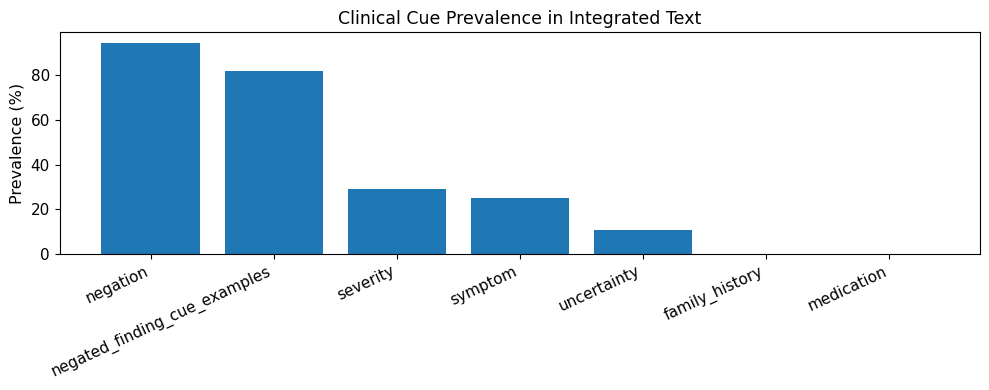

Saved cue summary: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\text_clinical_cue_summary.csv
Saved cue sample flags: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\text_clinical_cue_sample_flags.csv
Saved cue prevalence plot: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\text_clinical_cue_prevalence.png
Saved cue payload: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\text_clinical_cue_payload_02.json


In [10]:
# Step 6: Lightweight clinical cue profiling inspired by MIMIC-IV notes_preproc target/context rules

print("Running lightweight clinical cue profiling...")

text_df, source_name = resolve_pipeline_dataframe(step_label="Step 6: Clinical Cue Profiling")
text_col = resolve_text_column(text_df)
text_df[text_col] = text_df[text_col].fillna("").astype(str)

print(f"Using source: {source_name} (rows={len(text_df):,}) | column='{text_col}'")

df = text_df.copy()

# This is a cue-level lexical audit, not a full clinical NLP annotation step.
# Negation flags indicate that negation cues are present somewhere in the text;
# they do not prove that a specific disease/finding is negated.
lexicons = {
    "negation": [
        r"\bno\b",
        r"\bnot\b",
        r"\bdenies\b",
        r"\bwithout\b",
        r"\bnegative for\b",
        r"\bno evidence of\b",
        r"\black of\b",
    ],
    "severity": [
        r"\bmild\b",
        r"\bmoderate\b",
        r"\bsevere\b",
        r"\bcritical\b",
        r"\bworsening\b",
        r"\bimproved\b",
    ],
    "uncertainty": [
        r"\bpossible\b",
        r"\bprobably\b",
        r"\bprobable\b",
        r"\bsuggests\b",
        r"\bsuspicious for\b",
        r"\bcannot exclude\b",
        r"\bmay represent\b",
    ],
    "family_history": [
        r"\bfamily history\b",
        r"\bmother had\b",
        r"\bfather had\b",
        r"\bsister had\b",
        r"\bbrother had\b",
        r"\bmaternal\b",
        r"\bpaternal\b",
        r"\bhereditary\b",
        r"\bgenetic\b",
    ],
    "symptom": [
        r"\bshortness of breath\b",
        r"\bsob\b",
        r"\bchest pain\b",
        r"\bfever\b",
        r"\babdominal pain\b",
        r"\bheadache\b",
        r"\bfatigue\b",
        r"\bdiarrhea\b",
        r"\bedema\b",
        r"\bpalpitations\b",
    ],
    "medication": [
        r"\binsulin\b",
        r"\bheparin\b",
        r"\blasix\b",
        r"\bfurosemide\b",
        r"\bnorepinephrine\b",
        r"\bwarfarin\b",
        r"\bmetoprolol\b",
    ],
}

tracked_findings = [
    "pneumonia",
    "consolidation",
    "infiltrate",
    "pleural effusion",
    "effusion",
    "pulmonary edema",
    "edema",
    "cardiomegaly",
    "atelectasis",
    "opacity",
    "pneumothorax",
]


def _count_hits(text: str, patterns: list) -> int:
    txt = str(text).lower()
    return int(sum(len(re.findall(pattern, txt)) for pattern in patterns))


def _extract_negated_finding_cues(text: str, max_examples: int = 5) -> list:
    """
    Lightweight local negation cue extraction.
    This captures simple phrases like 'no pneumonia' or 'without pleural effusion'.
    It is not a replacement for full clinical negation scope parsing.
    """
    txt = re.sub(r"\s+", " ", str(text).lower()).strip()
    examples = []

    negation_prefixes = [
        r"no",
        r"not",
        r"without",
        r"negative for",
        r"no evidence of",
    ]

    for finding in tracked_findings:
        finding_pattern = re.escape(finding)

        for neg in negation_prefixes:
            pattern = rf"\b{neg}\b(?:\s+\w+){{0,4}}\s+\b{finding_pattern}\b"
            matches = re.findall(pattern, txt)

            for match in matches:
                examples.append(match.strip())
                if len(examples) >= max_examples:
                    return examples

    return examples


for cue_name, patterns in lexicons.items():
    df[f"cue_{cue_name}_count"] = df[text_col].apply(lambda t: _count_hits(t, patterns))
    df[f"cue_{cue_name}_flag"] = (df[f"cue_{cue_name}_count"] > 0).astype(int)

df["negated_finding_cue_examples"] = df[text_col].apply(_extract_negated_finding_cues)
df["negated_finding_cue_count"] = df["negated_finding_cue_examples"].apply(len)
df["negated_finding_cue_flag"] = (df["negated_finding_cue_count"] > 0).astype(int)

summary_rows = []

for cue_name in lexicons.keys():
    flag_col = f"cue_{cue_name}_flag"
    count_col = f"cue_{cue_name}_count"

    summary_rows.append({
        "cue": cue_name,
        "cue_type": "lexical_presence",
        "rows_with_cue": int(df[flag_col].sum()),
        "row_prevalence_pct": round(float(df[flag_col].mean() * 100.0), 4),
        "total_mentions": int(df[count_col].sum()),
        "avg_mentions_per_row": round(float(df[count_col].mean()), 4),
        "scope_resolved": False,
    })

summary_rows.append({
    "cue": "negated_finding_cue_examples",
    "cue_type": "local_pattern_example",
    "rows_with_cue": int(df["negated_finding_cue_flag"].sum()),
    "row_prevalence_pct": round(float(df["negated_finding_cue_flag"].mean() * 100.0), 4),
    "total_mentions": int(df["negated_finding_cue_count"].sum()),
    "avg_mentions_per_row": round(float(df["negated_finding_cue_count"].mean()), 4),
    "scope_resolved": False,
})

df_summary = (
    pd.DataFrame(summary_rows)
    .sort_values("rows_with_cue", ascending=False)
    .reset_index(drop=True)
)

display(df_summary)

summary_path = QUALITY_DIR / "text_clinical_cue_summary.csv"
samples_path = QUALITY_DIR / "text_clinical_cue_sample_flags.csv"
fig_path = QUALITY_DIR / "text_clinical_cue_prevalence.png"
payload_path = QUALITY_DIR / "text_clinical_cue_payload_02.json"

df_summary.to_csv(summary_path, index=False)

sample_cols = [c for c in ["subject_id", "stay_id", "hadm_id", "study_id", text_col] if c in df.columns]
sample_cols += [
    "cue_negation_flag",
    "cue_severity_flag",
    "cue_uncertainty_flag",
    "cue_family_history_flag",
    "cue_symptom_flag",
    "cue_medication_flag",
    "negated_finding_cue_flag",
    "negated_finding_cue_examples",
]

df[sample_cols].head(2000).to_csv(samples_path, index=False)

plt.figure(figsize=(10, 4))
plt.bar(df_summary["cue"], df_summary["row_prevalence_pct"])
plt.ylabel("Prevalence (%)")
plt.title("Clinical Cue Prevalence in Integrated Text")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
plt.show()

cue_payload = {
    "source": source_name,
    "rows": int(len(df)),
    "text_column": text_col,
    "cue_policy": {
        "method": "lexical_cue_audit",
        "negation_scope_resolved": False,
        "note": (
            "Negation flags indicate lexical cue presence only. "
            "negated_finding_cue_examples are lightweight local-pattern examples, "
            "not full clinical negation annotations."
        ),
    },
    "tracked_findings_for_negation_examples": tracked_findings,
    "summary_csv": str(summary_path),
    "sample_csv": str(samples_path),
    "plot": str(fig_path),
}

with open(payload_path, "w", encoding="utf-8") as f:
    json.dump(cue_payload, f, indent=2)

if "text_pipeline_audit" in globals():
    text_pipeline_audit.update({
        "clinical_cue_summary_csv": str(summary_path),
        "clinical_cue_sample_csv": str(samples_path),
        "clinical_cue_plot": str(fig_path),
        "clinical_cue_payload_json": str(payload_path),
        "clinical_cue_method": "lexical_cue_audit",
        "clinical_cue_negation_scope_resolved": False,
    })

print(f"Saved cue summary: {summary_path}")
print(f"Saved cue sample flags: {samples_path}")
print(f"Saved cue prevalence plot: {fig_path}")
print(f"Saved cue payload: {payload_path}")


**Step 7: Clinical Term Bank and Abbreviation Normalization Audit**

This optional enhancement builds a simple clinical term bank from the extracted text and audits common abbreviations. Conservative abbreviations are expanded, while ambiguous abbreviations are counted but not automatically normalized.

**Main Operations**  
◽ Resolve the active clinical-text dataframe and text column  
◽ Normalize text spacing and casing for term extraction  
◽ Expand selected low-risk abbreviations such as `SOB`, `HTN`, `DM`, and `COPD`  
◽ Count ambiguous abbreviations such as `PE` without automatic expansion  
◽ Extract frequent clinical terms from normalized text  
◽ Export term-frequency and abbreviation-audit tables  

**Technical and Clinical Significance**  
Clinical abbreviations can introduce ambiguity during text processing. This step improves transparency by separating safe normalization from ambiguous abbreviation handling. The resulting term bank can support later vocabulary review, prompt construction, retrieval indexing, or clinical concept inspection.

**Expected Outcome**  
A clinical term bank and abbreviation audit files are saved, including safe abbreviation expansions and ambiguous abbreviation counts.

In [11]:
# Step 7: CPLLM-inspired clinical term bank + abbreviation normalization audit

print("Starting Step 7: CPLLM-inspired term bank...")

text_df, source_name = resolve_pipeline_dataframe(step_label="Step 7: CPLLM Term Bank")
text_col = resolve_text_column(text_df, concat_col_name="cpllm_text_concat")
text_df[text_col] = text_df[text_col].fillna("").astype(str)

print(f"Text source: {source_name} (rows={len(text_df):,}) | column='{text_col}'")

# Conservative abbreviation map.
# These expansions are relatively common and lower-risk in radiology/clinical text.
abbrev_map = {
    "sob": "shortness of breath",
    "cp": "chest pain",
    "htn": "hypertension",
    "dm": "diabetes mellitus",
    "cad": "coronary artery disease",
    "chf": "congestive heart failure",
    "copd": "chronic obstructive pulmonary disease",
    "ards": "acute respiratory distress syndrome",
    "aki": "acute kidney injury",
}

# Ambiguous abbreviations are counted but not automatically expanded.
# Example: PE may mean pulmonary embolism, pleural effusion, pulmonary edema, or physical exam depending on context.
ambiguous_abbrev_map = {
    "pe": [
        "pulmonary embolism",
        "pleural effusion",
        "pulmonary edema",
        "physical exam",
    ],
}

word_pattern = re.compile(r"[a-z][a-z0-9\-]{2,}", flags=re.IGNORECASE)

raw_counter = Counter()
normalized_counter = Counter()
abbrev_hit_counter = Counter()
ambiguous_abbrev_hit_counter = Counter()

rows_with_safe_abbrev = 0
rows_with_ambiguous_abbrev = 0


def _normalize_text_for_terms(text: str) -> str:
    return re.sub(r"\s+", " ", str(text).lower()).strip()


def _replace_safe_abbreviations(text: str):
    found_safe = False

    for abbr, full in abbrev_map.items():
        pattern = rf"\b{re.escape(abbr)}\b"
        hits = len(re.findall(pattern, text, flags=re.IGNORECASE))

        if hits > 0:
            found_safe = True
            abbrev_hit_counter[abbr] += hits
            text = re.sub(pattern, full, text, flags=re.IGNORECASE)

    return text, found_safe


def _count_ambiguous_abbreviations(text: str) -> bool:
    found_ambiguous = False

    for abbr in ambiguous_abbrev_map.keys():
        pattern = rf"\b{re.escape(abbr)}\b"
        hits = len(re.findall(pattern, text, flags=re.IGNORECASE))

        if hits > 0:
            found_ambiguous = True
            ambiguous_abbrev_hit_counter[abbr] += hits

    return found_ambiguous


for txt in text_df[text_col].tolist():
    txt = _normalize_text_for_terms(txt)
    if not txt:
        continue

    has_ambiguous = _count_ambiguous_abbreviations(txt)
    if has_ambiguous:
        rows_with_ambiguous_abbrev += 1

    txt, has_safe = _replace_safe_abbreviations(txt)
    if has_safe:
        rows_with_safe_abbrev += 1

    terms = word_pattern.findall(txt)

    for term in terms:
        term = term.strip().lower()
        if 4 <= len(term) <= 50:
            raw_counter[term] += 1
            normalized_counter[term] += 1

# Ensure canonical expanded concepts appear in the exported schema,
# even if their frequency is zero after filtering.
for _, full in abbrev_map.items():
    normalized_counter[full] += 0

term_rows = []
for term, freq in normalized_counter.items():
    if freq >= 3:
        term_rows.append({
            "term": term,
            "frequency": int(freq),
            "term_source": "normalized_text_frequency",
        })

term_df = (
    pd.DataFrame(term_rows)
    .sort_values(["frequency", "term"], ascending=[False, True])
    .reset_index(drop=True)
)

if len(term_df) == 0:
    term_df = pd.DataFrame([{
        "term": "NO_TERMS_FOUND",
        "frequency": 0,
        "term_source": "empty_result",
    }])

safe_abbrev_df = pd.DataFrame([
    {
        "abbreviation": abbr,
        "expanded_form": full,
        "hit_count": int(abbrev_hit_counter.get(abbr, 0)),
        "normalization_policy": "expanded",
    }
    for abbr, full in abbrev_map.items()
])

ambiguous_abbrev_df = pd.DataFrame([
    {
        "abbreviation": abbr,
        "possible_meanings": "; ".join(possible_meanings),
        "hit_count": int(ambiguous_abbrev_hit_counter.get(abbr, 0)),
        "normalization_policy": "not_expanded_ambiguous",
    }
    for abbr, possible_meanings in ambiguous_abbrev_map.items()
])

audit_df = pd.DataFrame([
    {"metric": "source", "value": source_name},
    {"metric": "rows", "value": int(len(text_df))},
    {"metric": "text_column", "value": text_col},
    {"metric": "safe_abbreviations_expanded", "value": int(len(abbrev_map))},
    {"metric": "ambiguous_abbreviations_not_expanded", "value": int(len(ambiguous_abbrev_map))},
    {"metric": "rows_with_safe_abbreviation_hits", "value": int(rows_with_safe_abbrev)},
    {
        "metric": "safe_abbreviation_hit_rate_pct",
        "value": round((rows_with_safe_abbrev / max(len(text_df), 1)) * 100.0, 4),
    },
    {"metric": "rows_with_ambiguous_abbreviation_hits", "value": int(rows_with_ambiguous_abbrev)},
    {
        "metric": "ambiguous_abbreviation_hit_rate_pct",
        "value": round((rows_with_ambiguous_abbrev / max(len(text_df), 1)) * 100.0, 4),
    },
    {"metric": "term_rows_exported", "value": int(len(term_df))},
])

term_csv = QUALITY_DIR / "cpllm_text_term_bank_02.csv"
audit_csv = QUALITY_DIR / "cpllm_text_normalization_audit_02.csv"
safe_abbrev_csv = QUALITY_DIR / "cpllm_safe_abbreviation_expansion_02.csv"
ambiguous_abbrev_csv = QUALITY_DIR / "cpllm_ambiguous_abbreviation_audit_02.csv"
term_json = OUTPUTS_DIR / "cpllm_term_bank_02.json"

term_df.head(15000).to_csv(term_csv, index=False)
audit_df.to_csv(audit_csv, index=False)
safe_abbrev_df.to_csv(safe_abbrev_csv, index=False)
ambiguous_abbrev_df.to_csv(ambiguous_abbrev_csv, index=False)

with open(term_json, "w", encoding="utf-8") as f:
    json.dump({
        "source": source_name,
        "text_column": text_col,
        "normalization_policy": {
            "safe_abbreviations": abbrev_map,
            "ambiguous_abbreviations_not_expanded": ambiguous_abbrev_map,
            "note": (
                "Ambiguous abbreviations are counted for audit but not expanded "
                "without context-aware disambiguation."
            ),
        },
        "terms": term_df.head(5000).to_dict(orient="records"),
    }, f, indent=2)

if "text_pipeline_audit" in globals():
    text_pipeline_audit.update({
        "cpllm_term_bank_csv": str(term_csv),
        "cpllm_normalization_audit_csv": str(audit_csv),
        "cpllm_safe_abbreviation_csv": str(safe_abbrev_csv),
        "cpllm_ambiguous_abbreviation_csv": str(ambiguous_abbrev_csv),
        "cpllm_term_bank_json": str(term_json),
        "cpllm_rows_with_safe_abbreviation_hits": int(rows_with_safe_abbrev),
        "cpllm_rows_with_ambiguous_abbreviation_hits": int(rows_with_ambiguous_abbrev),
    })

print(f"Saved CPLLM term bank: {term_csv}")
print(f"Saved normalization audit: {audit_csv}")
print(f"Saved safe abbreviation expansion audit: {safe_abbrev_csv}")
print(f"Saved ambiguous abbreviation audit: {ambiguous_abbrev_csv}")
print(f"Saved term-bank JSON: {term_json}")

display(audit_df)


Starting Step 7: CPLLM-inspired term bank...
Text source: df_integrated (rows=88,570) | column='clinical_text'
Saved CPLLM term bank: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cpllm_text_term_bank_02.csv
Saved normalization audit: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cpllm_text_normalization_audit_02.csv
Saved safe abbreviation expansion audit: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cpllm_safe_abbreviation_expansion_02.csv
Saved ambiguous abbreviation audit: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cpllm_ambiguous_abbreviation_audit_02.csv
Saved term-bank JSON: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\cpllm_term_bank_02.json


,metric,value
0,source,df_integrated
1,rows,88570
2,text_column,clinical_text
3,safe_abbreviations_expanded,9
4,ambiguous_abbreviations_not_expanded,1
5,rows_with_safe_abbreviation_hits,2521
6,safe_abbreviation_hit_rate_pct,2.8463
7,rows_with_ambiguous_abbreviation_hits,17
8,ambiguous_abbreviation_hit_rate_pct,0.0192
9,term_rows_exported,4150


**Step 8: Chain-of-Evidence Draft Packaging**

This optional dataset-preparation step creates draft reasoning-style examples from clinical text. It uses weak keyword rules to assign provisional labels and packages each example with a short evidence-oriented explanation.

**Main Operations**  
◽ Resolve the active clinical-text dataframe and text column  
◽ Apply keyword-based weak-label rules for selected clinical conditions  
◽ Use a simple negation check to reduce obvious false-positive label matches  
◽ Assign `Other` when no predefined cue is detected  
◽ Build draft evidence text from matched cues and source snippets  
◽ Export Chain-of-Evidence draft records and summary statistics  

**Technical and Clinical Significance**  
This step prepares audit-first reasoning examples that can support later instruction-generation experiments. The weak labels are not clinical ground truth and are only suitable for draft packaging, error analysis, and prompt-development workflows.

**Expected Outcome**  
A draft Chain-of-Evidence dataset is generated, with weak labels, matched cues, negated cue information, and evidence-style text fields.

In [12]:
# Step 8: MedTVT-R1 text-to-CoE draft packaging (audit-first)

print("Starting Step 8: MedTVT text-to-CoE packaging...")

text_df, source_name = resolve_pipeline_dataframe(step_label="Step 8: MedTVT CoE Packaging")
text_col = resolve_text_column(text_df, concat_col_name="medtvt_text_concat")
text_df[text_col] = text_df[text_col].fillna("").astype(str)

print(f"Text source: {source_name} (rows={len(text_df):,}) | column='{text_col}'")

label_rules = {
    "Atherosclerotic Heart Disease Without Angina Pectoris": [
        "coronary",
        "ischemia",
        "atherosclerotic",
        "cad",
    ],
    "Acute Kidney Failure, Unspecified": [
        "acute kidney",
        "aki",
        "creatinine rising",
        "renal failure",
    ],
    "Essential (Primary) Hypertension": [
        "hypertension",
        "htn",
        "high blood pressure",
    ],
    "Atrial Fibrillation": [
        "atrial fibrillation",
        "afib",
        "irregularly irregular",
    ],
    "Pneumonia, Unspecified Organism": [
        "pneumonia",
        "consolidation",
        "infiltrate",
    ],
    "Type 2 diabetes mellitus without complications": [
        "diabetes",
        "dm",
        "hyperglycemia",
    ],
    "Sepsis, unspecified organism": [
        "sepsis",
        "septic",
        "bacteremia",
    ],
    "Chronic Obstructive Pulmonary Disease (COPD), Unspecified": [
        "copd",
        "emphysema",
        "chronic obstructive",
    ],
}

weak_label_policy = {
    "label_source": "weak_keyword_heuristic",
    "ground_truth_status": "not_ground_truth",
    "intended_use": "draft_instruction_packaging_only",
    "not_valid_for": [
        "clinical_evaluation",
        "model_performance_reporting",
        "ground_truth_supervision_without_validation",
    ],
    "warning": (
        "Labels are inferred from surface keyword matches in clinical text. "
        "They must not be interpreted as clinically validated diagnoses."
    ),
}


def _normalize_for_matching(text: str) -> str:
    return re.sub(r"\s+", " ", str(text).lower()).strip()


def _is_negated_near_cue(text: str, cue: str, window_chars: int = 45) -> bool:
    """
    Lightweight local negation check.
    This reduces obvious false positives such as 'no pneumonia' or
    'without pleural effusion', but it is not full clinical negation scope parsing.
    """
    negation_patterns = [
        r"\bno\b",
        r"\bnot\b",
        r"\bwithout\b",
        r"\bnegative for\b",
        r"\bno evidence of\b",
        r"\bno focal\b",
        r"\bno acute\b",
        r"\bdenies\b",
    ]

    cue_pattern = re.compile(rf"\b{re.escape(cue)}\b", flags=re.IGNORECASE)

    for match in cue_pattern.finditer(text):
        start = max(0, match.start() - window_chars)
        context_before = text[start:match.start()]
        if any(re.search(pat, context_before, flags=re.IGNORECASE) for pat in negation_patterns):
            return True

    return False


def _extract_weak_labels(text: str):
    normalized_text = _normalize_for_matching(text)

    found_labels = []
    matched_cues = []
    negated_cues = []

    for label, cues in label_rules.items():
        for cue in cues:
            cue_pattern = rf"\b{re.escape(cue)}\b"

            if not re.search(cue_pattern, normalized_text):
                continue

            if _is_negated_near_cue(normalized_text, cue):
                negated_cues.append({"label": label, "cue": cue})
                continue

            found_labels.append(label)
            matched_cues.append({"label": label, "cue": cue})
            break

    if not found_labels:
        found_labels = ["Other"]

    return found_labels, matched_cues, negated_cues


def _build_think(text: str, labels: list, matched_cues: list, negated_cues: list) -> str:
    t = re.sub(r"\s+", " ", str(text)).strip()
    snippet = t[:280] + ("..." if len(t) > 280 else "")
    joined_labels = "; ".join(labels[:4])

    cue_terms = [item["cue"] for item in matched_cues[:6]]
    cue_summary = ", ".join(cue_terms) if cue_terms else "no non-negated keyword cues"

    negated_terms = [item["cue"] for item in negated_cues[:6]]
    negation_summary = ", ".join(negated_terms) if negated_terms else "none detected"

    return (
        "Weak keyword-based draft only. "
        f"Candidate labels: {joined_labels}. "
        f"Matched cues: {cue_summary}. "
        f"Negated cues ignored: {negation_summary}. "
        f"Evidence snippet: {snippet}"
    )


records = []

for row_idx, row in text_df.iterrows():
    narrative = str(row.get(text_col, "")).strip()

    weak_labels, matched_cues, negated_cues = _extract_weak_labels(narrative)
    think = _build_think(narrative, weak_labels, matched_cues, negated_cues)
    answer = ";".join(weak_labels)
    coe = f"<think>{think}</think><answer>{answer}</answer>"

    records.append({
        "row_index": int(row_idx),
        "messages": [
            {
                "role": "user",
                "content": (
                    "Review the following clinical text with multimodal placeholders "
                    f"<ecg> <cxr> <lab>. Text: {narrative}"
                ),
            },
            {
                "role": "assistant",
                "content": coe,
            },
        ],
        "weak_keyword_labels": weak_labels,
        "draft_labels": weak_labels,
        "matched_keyword_cues": matched_cues,
        "negated_keyword_cues": negated_cues,
        "label_source": weak_label_policy["label_source"],
        "ground_truth_status": weak_label_policy["ground_truth_status"],
        "intended_use": weak_label_policy["intended_use"],
    })

pack_df = pd.DataFrame(records)

label_count = int(sum(1 for r in records if "Other" not in r["weak_keyword_labels"]))
rows_with_negated_cues = int(sum(1 for r in records if len(r["negated_keyword_cues"]) > 0))
total_matched_cues = int(sum(len(r["matched_keyword_cues"]) for r in records))
total_negated_cues = int(sum(len(r["negated_keyword_cues"]) for r in records))

summary_df = pd.DataFrame([
    {"metric": "source", "value": source_name},
    {"metric": "rows", "value": int(len(pack_df))},
    {"metric": "text_column", "value": text_col},
    {"metric": "label_source", "value": weak_label_policy["label_source"]},
    {"metric": "ground_truth_status", "value": weak_label_policy["ground_truth_status"]},
    {"metric": "intended_use", "value": weak_label_policy["intended_use"]},
    {"metric": "rows_with_non_other_weak_label", "value": label_count},
    {
        "metric": "rows_with_non_other_weak_label_pct",
        "value": round(float(label_count / max(len(pack_df), 1) * 100.0), 4),
    },
    {"metric": "rows_with_negated_cues", "value": rows_with_negated_cues},
    {
        "metric": "rows_with_negated_cues_pct",
        "value": round(float(rows_with_negated_cues / max(len(pack_df), 1) * 100.0), 4),
    },
    {"metric": "total_matched_keyword_cues", "value": total_matched_cues},
    {"metric": "total_negated_keyword_cues_ignored", "value": total_negated_cues},
])

audit_path = QUALITY_DIR / "medtvt_text_to_answer_audit_02.csv"
preview_path = QUALITY_DIR / "medtvt_text_to_answer_preview_02.csv"
jsonl_path = OUTPUTS_DIR / "medtvt_text_reasoning_pack_02.jsonl"
payload_path = QUALITY_DIR / "medtvt_text_to_answer_payload_02.json"

summary_df.to_csv(audit_path, index=False)
pack_df.head(3000).to_csv(preview_path, index=False)
pack_df.to_json(jsonl_path, orient="records", lines=True, force_ascii=False)

with open(payload_path, "w", encoding="utf-8") as f:
    json.dump({
        "source": source_name,
        "rows": int(len(pack_df)),
        "text_column": text_col,
        "label_policy": weak_label_policy,
        "non_other_weak_label_pct": round(
            float(label_count / max(len(pack_df), 1) * 100.0), 4
        ),
        "rows_with_negated_cues": rows_with_negated_cues,
        "total_matched_keyword_cues": total_matched_cues,
        "total_negated_keyword_cues_ignored": total_negated_cues,
        "jsonl": str(jsonl_path),
    }, f, indent=2)

if "text_pipeline_audit" in globals():
    text_pipeline_audit.update({
        "medtvt_text_audit_file": str(audit_path),
        "medtvt_text_preview_file": str(preview_path),
        "medtvt_text_pack_file": str(jsonl_path),
        "medtvt_text_payload_file": str(payload_path),
        "medtvt_label_source": weak_label_policy["label_source"],
        "medtvt_ground_truth_status": weak_label_policy["ground_truth_status"],
        "medtvt_rows_with_non_other_weak_label": label_count,
        "medtvt_rows_with_negated_cues": rows_with_negated_cues,
    })

print(f"Saved MedTVT text audit: {audit_path}")
print(f"Saved MedTVT text preview: {preview_path}")
print(f"Saved MedTVT text pack: {jsonl_path}")
print(f"Saved MedTVT text payload: {payload_path}")

display(summary_df)


Starting Step 8: MedTVT text-to-CoE packaging...
Text source: df_integrated (rows=88,570) | column='clinical_text'
Saved MedTVT text audit: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtvt_text_to_answer_audit_02.csv
Saved MedTVT text preview: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtvt_text_to_answer_preview_02.csv
Saved MedTVT text pack: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medtvt_text_reasoning_pack_02.jsonl
Saved MedTVT text payload: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtvt_text_to_answer_payload_02.json


,metric,value
0,source,df_integrated
1,rows,88570
2,text_column,clinical_text
3,label_source,weak_keyword_heuristic
4,ground_truth_status,not_ground_truth
5,intended_use,draft_instruction_packaging_only
6,rows_with_non_other_weak_label,17210
7,rows_with_non_other_weak_label_pct,19.431
8,rows_with_negated_cues,40411
9,rows_with_negated_cues_pct,45.6261


**Step 9: Prompt-Contract Normalization for Clinical Text Instructions**

This optional dataset-preparation step converts clinical text records into structured instruction prompts. Each prompt requires a JSON-only response format and emphasizes faithful summarization, preservation of negation, and avoidance of unsupported diagnoses.

**Main Operations**  
◽ Resolve the active clinical-text dataframe and text column  
◽ Normalize and truncate long clinical text inputs for prompt construction  
◽ Infer a text-only clinical task type from report content  
◽ Build a task-specific JSON response schema  
◽ Generate normalized prompts with explicit clinical safety instructions  
◽ Audit prompt properties such as JSON-contract presence and image-token absence  

**Technical and Clinical Significance**  
Prompt-contract normalization makes later instruction datasets more consistent and easier to evaluate. Requiring structured JSON responses also supports automated checking of key fields such as findings, negated findings, uncertainty terms, evidence spans, and limitations.

**Expected Outcome**  
A normalized clinical prompt dataset is created for text-only instruction-tuning or evaluation workflows.

In [13]:
# Step 9: Clinical text prompt-contract normalization (audit-first)

print("Starting Step 9: Clinical text prompt-contract normalization...")

text_df, source_name = resolve_pipeline_dataframe(step_label="Step 9: Clinical Text Prompt Contract")
text_col = resolve_text_column(text_df, concat_col_name="clinical_prompt_text_concat")
text_df[text_col] = text_df[text_col].fillna("").astype(str)

print(f"Text source: {source_name} (rows={len(text_df):,}) | column='{text_col}'")


def _normalize_prompt_text(text: str, max_chars: int = 900) -> str:
    text = re.sub(r"\s+", " ", str(text)).strip()
    if len(text) > max_chars:
        return text[:max_chars].rstrip() + "..."
    return text


def _infer_clinical_text_task(text: str) -> str:
    """
    Infer a text-only clinical instruction family.
    This is not an image localization or bounding-box task.
    """
    x = str(text).lower()

    has_negation = bool(re.search(r"\b(no|without|negative for|no evidence of|denies)\b", x))
    has_severity = bool(re.search(r"\b(mild|moderate|severe|critical|worsening|improved)\b", x))
    has_impression = "impression:" in x
    has_findings = "findings:" in x
    has_many_findings = len(re.findall(r"\b(pneumonia|effusion|edema|opacity|consolidation|atelectasis|cardiomegaly)\b", x)) >= 2

    if has_findings and has_impression:
        return "radiology_report_structuring"
    if has_negation and has_severity:
        return "clinical_evidence_extraction"
    if has_many_findings:
        return "finding_summary"
    if has_negation:
        return "negation_aware_summary"
    return "clinical_text_review"


def _contract_schema(task: str) -> dict:
    base_schema = {
        "task": task,
        "summary": "short clinically faithful summary",
        "key_findings": ["finding_1", "finding_2"],
        "negated_findings": ["negated_finding_1"],
        "severity_terms": ["mild|moderate|severe|critical if present"],
        "uncertainty_terms": ["possible|probable|suggests if present"],
        "evidence_spans": ["brief source phrases copied from the input"],
        "limitations": ["state if information is insufficient"],
    }

    if task == "radiology_report_structuring":
        base_schema.update({
            "findings_summary": "summary of objective imaging findings",
            "impression_summary": "summary of radiologist impression",
        })

    if task == "clinical_evidence_extraction":
        base_schema.update({
            "positive_evidence": ["non-negated clinical evidence"],
            "negative_evidence": ["negated or absent findings"],
        })

    return base_schema


def _contract_line(task: str) -> str:
    schema = _contract_schema(task)
    return (
        "Return only valid JSON using this schema: "
        + json.dumps(schema, ensure_ascii=False)
    )


records = []

for row_idx, row in text_df.iterrows():
    raw_text = str(row.get(text_col, "")).strip()
    task = _infer_clinical_text_task(raw_text)

    base_prompt = _normalize_prompt_text(raw_text, max_chars=900)
    if not base_prompt:
        base_prompt = "No clinical text was provided."

    normalized_prompt = (
        "Review the following clinical text. "
        "Do not invent diagnoses or findings. "
        "Preserve negation and uncertainty. "
        f"Clinical text: {base_prompt} "
        f"{_contract_line(task)}"
    ).strip()

    records.append({
        "row_index": int(row_idx),
        "source_text": raw_text,
        "task": task,
        "normalized_prompt": normalized_prompt,
        "has_image_token": int("<image>" in normalized_prompt.lower()),
        "has_json_contract": int("return only valid json" in normalized_prompt.lower()),
        "contract_type": "clinical_text_json",
        "alignment_status": "text_only_clinical_contract",
    })

out_df = pd.DataFrame(records)

task_counts = out_df["task"].value_counts().to_dict()

summary_rows = [
    {"metric": "source", "value": source_name},
    {"metric": "rows", "value": int(len(out_df))},
    {"metric": "text_column", "value": text_col},
    {"metric": "contract_type", "value": "clinical_text_json"},
    {"metric": "alignment_status", "value": "text_only_clinical_contract"},
    {"metric": "has_image_token_pct", "value": round(float(out_df["has_image_token"].mean() * 100.0), 4)},
    {"metric": "has_json_contract_pct", "value": round(float(out_df["has_json_contract"].mean() * 100.0), 4)},
]

for task_name, count in task_counts.items():
    summary_rows.append({
        "metric": f"task_{task_name}_rows",
        "value": int(count),
    })

summary_df = pd.DataFrame(summary_rows)

audit_path = QUALITY_DIR / "pointdetect_prompt_contract_audit_02.csv"
preview_path = QUALITY_DIR / "pointdetect_prompt_contract_preview_02.csv"
jsonl_path = OUTPUTS_DIR / "pointdetect_prompt_contract_pack_02.jsonl"
payload_path = QUALITY_DIR / "pointdetect_prompt_contract_payload_02.json"

summary_df.to_csv(audit_path, index=False)
out_df.head(3000).to_csv(preview_path, index=False)
out_df[["task", "normalized_prompt", "contract_type"]].to_json(
    jsonl_path,
    orient="records",
    lines=True,
    force_ascii=False,
)

with open(payload_path, "w", encoding="utf-8") as f:
    json.dump({
        "source": source_name,
        "rows": int(len(out_df)),
        "text_column": text_col,
        "contract_type": "clinical_text_json",
        "alignment_status": "text_only_clinical_contract",
        "task_counts": {str(k): int(v) for k, v in task_counts.items()},
        "jsonl": str(jsonl_path),
    }, f, indent=2)

if "text_pipeline_audit" in globals():
    text_pipeline_audit.update({
        "pointdetect_prompt_contract_audit_file": str(audit_path),
        "pointdetect_prompt_contract_preview_file": str(preview_path),
        "pointdetect_prompt_contract_pack_file": str(jsonl_path),
        "pointdetect_prompt_contract_payload_file": str(payload_path),
        "pointdetect_contract_type": "clinical_text_json",
        "pointdetect_alignment_status": "text_only_clinical_contract",
    })

print(f"Saved PointDetect-compatible clinical text audit: {audit_path}")
print(f"Saved PointDetect-compatible clinical text preview: {preview_path}")
print(f"Saved PointDetect-compatible clinical text pack: {jsonl_path}")
print(f"Saved PointDetect-compatible clinical text payload: {payload_path}")

display(summary_df)


Starting Step 9: Clinical text prompt-contract normalization...
Text source: df_integrated (rows=88,570) | column='clinical_text'
Saved PointDetect-compatible clinical text audit: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\pointdetect_prompt_contract_audit_02.csv
Saved PointDetect-compatible clinical text preview: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\pointdetect_prompt_contract_preview_02.csv
Saved PointDetect-compatible clinical text pack: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\pointdetect_prompt_contract_pack_02.jsonl
Saved PointDetect-compatible clinical text payload: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\pointdetect_prompt_contract_payload_02.json


,metric,value
0,source,df_integrated
1,rows,88570
2,text_column,clinical_text
3,contract_type,clinical_text_json
4,alignment_status,text_only_clinical_contract
5,has_image_token_pct,0.0
6,has_json_contract_pct,100.0
7,task_radiology_report_structuring_rows,76906
8,task_negation_aware_summary_rows,3919
9,task_finding_summary_rows,3772


**Step 10: Retrieval-Ready Clinical Note Chunk Packaging**

This optional retrieval-preparation step splits clinical text into smaller chunks suitable for indexing and retrieval workflows. Each chunk receives a stable identifier and metadata needed for patient-level traceability.

**Main Operations**  
◽ Resolve the active clinical-text dataframe and text column  
◽ Identify the best available patient identifier column  
◽ Create fallback patient IDs when no patient identifier is available  
◽ Normalize clinical text and split it into sentence-aware chunks  
◽ Assign stable `chunk_id`, `source_id`, and row-level metadata  
◽ Check for duplicate chunk identifiers  
◽ Export chunk records and retrieval-preparation summaries  

**Technical and Clinical Significance**  
Retrieval systems work better when long clinical narratives are divided into manageable, traceable text units. This step prepares the report text for later retrieval-augmented generation while preserving links back to the original patient, study, and source row whenever those identifiers are available.

**Expected Outcome**  
A retrieval-ready clinical text chunk dataset is generated with chunk-level metadata, word counts, source identifiers, and retrieval-method hints.

In [14]:
# Step 10: xHAIM clinical note chunk contract pack (audit-first)

print("Starting Step 10: xHAIM clinical note chunk contract pack...")

# Resolve text dataframe via shared pipeline utility
text_df, source_name = resolve_pipeline_dataframe(step_label="Step 10: xHAIM Chunk Pack")

patient_col = next(
    (
        c for c in [
            "subject_id",
            "PatientMRN",
            "patient_id",
            "identifier",
            "stay_id",
            "hadm_id",
        ]
        if c in text_df.columns
    ),
    None,
)

text_col = next(
    (
        c for c in [
            "clinical_text",
            "note_text",
            "text",
            "chiefcomplaint",
            "history_of_present_illness",
            "discharge_summary",
        ]
        if c in text_df.columns
    ),
    None,
)

if patient_col is None:
    text_df["_xhaim_patient_id"] = [f"patient_{i:07d}" for i in range(len(text_df))]
    patient_col = "_xhaim_patient_id"

if text_col is None:
    object_cols = [c for c in text_df.columns if text_df[c].dtype == object and c != patient_col]
    if not object_cols:
        raise RuntimeError("No text-like column found for xHAIM Step 10 in notebook 02.")
    text_col = object_cols[0]

text_df = text_df.reset_index(drop=True).copy()
text_df[patient_col] = text_df[patient_col].fillna("").astype(str)
text_df[text_col] = text_df[text_col].fillna("").astype(str)


def _normalize(x: str) -> str:
    x = str(x).replace("\u00a0", " ")
    x = re.sub(r"\s+", " ", x).strip()
    return x


def _safe_id(value) -> str:
    value = str(value).strip()
    if not value or value.lower() in {"nan", "none", "null"}:
        return "missing"
    value = re.sub(r"[^A-Za-z0-9]+", "-", value)
    return value.strip("-") or "missing"


def _row_source_id(row: pd.Series, row_idx: int) -> str:
    id_parts = []

    for col in ["study_id", "hadm_id", "stay_id"]:
        if col in row.index:
            value = _safe_id(row.get(col, ""))
            if value != "missing":
                id_parts.append(f"{col}-{value}")

    if not id_parts:
        id_parts.append(f"row-{row_idx:07d}")
    else:
        id_parts.append(f"row-{row_idx:07d}")

    return "_".join(id_parts)


def _split_chunks(text: str, max_words: int = 180):
    text = _normalize(text)
    if not text:
        return []

    sentences = [s.strip() for s in re.split(r"(?<=[\.!?])\s+", text) if s.strip()]
    if not sentences:
        sentences = [text]

    chunks = []
    curr = []
    curr_words = 0

    for sentence in sentences:
        word_count = len(sentence.split())

        if curr and curr_words + word_count > max_words:
            chunks.append(" ".join(curr).strip())
            curr = [sentence]
            curr_words = word_count
        else:
            curr.append(sentence)
            curr_words += word_count

    if curr:
        chunks.append(" ".join(curr).strip())

    return [chunk for chunk in chunks if chunk]


rows = []

for row_idx, row in text_df.iterrows():
    patient_id = _safe_id(row.get(patient_col, ""))
    source_id = _row_source_id(row, row_idx)
    text = str(row.get(text_col, "")).strip()

    parts = _split_chunks(text, max_words=180)
    if not parts:
        continue

    for chunk_idx, chunk in enumerate(parts, start=1):
        rows.append({
            "patient_id": patient_id,
            "source_row_index": int(row_idx),
            "source_id": source_id,
            "chunk_id": f"{patient_id}_{source_id}_chunk-{chunk_idx:03d}",
            "chunk_index": int(chunk_idx),
            "chunk_text": chunk,
            "word_count": int(len(chunk.split())),
            "source_type": "radiology_report_text",
            "retrieval_method_hint": "hybrid",
        })

chunk_df = pd.DataFrame(rows)

if len(chunk_df) == 0:
    raise RuntimeError("xHAIM chunk pack produced zero rows in notebook 02.")

duplicate_chunk_ids = int(chunk_df["chunk_id"].duplicated().sum())
if duplicate_chunk_ids > 0:
    duplicated_examples = (
        chunk_df.loc[chunk_df["chunk_id"].duplicated(keep=False), "chunk_id"]
        .drop_duplicates()
        .head(20)
        .tolist()
    )
    raise RuntimeError(
        "Duplicate chunk_id values detected in xHAIM Step 10. "
        f"Duplicate count: {duplicate_chunk_ids}. "
        f"Examples: {duplicated_examples}"
    )

# Build simple lexical query packs.
query_pack = {
    "death_less_48hr": [
        "mortality risk",
        "hemodynamic instability",
        "vasopressor support",
        "critical deterioration",
    ],
    "pneumonia": [
        "pneumonia",
        "consolidation",
        "infiltrate",
        "respiratory distress",
    ],
    "pleural_effusion": [
        "pleural effusion",
        "pleural fluid",
        "blunting costophrenic angle",
        "thoracentesis",
    ],
    "cardiomegaly": [
        "cardiomegaly",
        "enlarged cardiac silhouette",
        "heart failure",
        "pulmonary edema",
    ],
}

audit_df = pd.DataFrame([
    {"metric": "source", "value": source_name},
    {"metric": "patient_column", "value": patient_col},
    {"metric": "text_column", "value": text_col},
    {"metric": "chunk_rows", "value": int(len(chunk_df))},
    {"metric": "unique_chunk_ids", "value": int(chunk_df["chunk_id"].nunique())},
    {"metric": "duplicate_chunk_ids", "value": duplicate_chunk_ids},
    {"metric": "unique_patients", "value": int(chunk_df["patient_id"].nunique())},
    {"metric": "unique_source_ids", "value": int(chunk_df["source_id"].nunique())},
    {"metric": "mean_chunk_words", "value": round(float(chunk_df["word_count"].mean()), 4)},
    {"metric": "max_chunk_words", "value": int(chunk_df["word_count"].max())},
    {"metric": "query_conditions", "value": int(len(query_pack))},
])

chunk_path = OUTPUTS_DIR / "xhaim_note_chunks_02.csv"
query_path = OUTPUTS_DIR / "xhaim_query_lexicon_02.json"
audit_path = QUALITY_DIR / "xhaim_text_chunk_contract_02.csv"
payload_path = QUALITY_DIR / "xhaim_text_chunk_payload_02.json"

chunk_df.to_csv(chunk_path, index=False)
audit_df.to_csv(audit_path, index=False)

with open(query_path, "w", encoding="utf-8") as f:
    json.dump({"source": source_name, "queries": query_pack}, f, indent=2)

with open(payload_path, "w", encoding="utf-8") as f:
    json.dump({
        "source": source_name,
        "patient_column": patient_col,
        "text_column": text_col,
        "rows": int(len(chunk_df)),
        "unique_chunk_ids": int(chunk_df["chunk_id"].nunique()),
        "duplicate_chunk_ids": duplicate_chunk_ids,
        "chunk_file": str(chunk_path),
        "audit_file": str(audit_path),
        "query_file": str(query_path),
    }, f, indent=2)

if "text_pipeline_audit" in globals():
    text_pipeline_audit.update({
        "xhaim_chunk_file": str(chunk_path),
        "xhaim_query_file": str(query_path),
        "xhaim_chunk_audit_file": str(audit_path),
        "xhaim_chunk_payload_file": str(payload_path),
        "xhaim_chunk_rows": int(len(chunk_df)),
        "xhaim_unique_chunk_ids": int(chunk_df["chunk_id"].nunique()),
        "xhaim_duplicate_chunk_ids": duplicate_chunk_ids,
    })

print(f"Saved xHAIM note chunks: {chunk_path}")
print(f"Saved xHAIM query lexicon: {query_path}")
print(f"Saved xHAIM text chunk audit: {audit_path}")
print(f"Saved xHAIM text chunk payload: {payload_path}")

display(audit_df)


Starting Step 10: xHAIM clinical note chunk contract pack...
Saved xHAIM note chunks: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\xhaim_note_chunks_02.csv
Saved xHAIM query lexicon: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\xhaim_query_lexicon_02.json
Saved xHAIM text chunk audit: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\xhaim_text_chunk_contract_02.csv
Saved xHAIM text chunk payload: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\xhaim_text_chunk_payload_02.json


,metric,value
0,source,df_integrated
1,patient_column,subject_id
2,text_column,clinical_text
3,chunk_rows,88861
4,unique_chunk_ids,88861
5,duplicate_chunk_ids,0
6,unique_patients,52196
7,unique_source_ids,88570
8,mean_chunk_words,57.8636
9,max_chunk_words,180


**Final Step: Consolidated Preprocessing Audit Export**

This final step saves the complete preprocessing audit trace for the full clinical text pipeline. It consolidates key statistics, output paths, quality-control artifacts, and final execution status into a single JSON file.

**Main Operations**  
◽ Confirm that the audit dictionary exists  
◽ Add final execution status to the audit record  
◽ Count generated output and quality-control files  
◽ Store the final output and quality-report directory paths  
◽ Save the consolidated audit report as `text_preprocessing_audit.json`  

**Technical and Clinical Significance**  
A consolidated audit file provides a reproducible record of the preprocessing run. This makes the notebook easier to review, debug, and reuse in later stages of dataset construction, model development, and explainability analysis.

**Expected Outcome**  
The final preprocessing audit JSON file is saved, and the clinical text preprocessing pipeline is completed successfully.

In [15]:
# Final Step: Export Preprocessing Audit Traceability Matrix

print("Saving final preprocessing audit report...")

# Define final audit path (overwrites the Step 5 intermediate version)
final_audit_path = QUALITY_DIR / "text_preprocessing_audit.json"

# Ensure text_pipeline_audit exists even if optional steps were skipped
if "text_pipeline_audit" not in globals():
    text_pipeline_audit = {}

# Capture final session summary
text_pipeline_audit.update({
    "final_execution_status": "Success",
    "total_output_files_generated": (
        len(list(OUTPUTS_DIR.glob("*"))) + len(list(QUALITY_DIR.glob("*")))
    ),
    "outputs_path": str(OUTPUTS_DIR),
    "quality_reports_path": str(QUALITY_DIR),
})

# Write consolidated audit JSON
with open(final_audit_path, "w", encoding="utf-8") as f:
    json.dump(text_pipeline_audit, f, indent=4, ensure_ascii=False)

print(f"📊 Final audit report saved : {final_audit_path}")
print(f"   Total tracked files      : {text_pipeline_audit['total_output_files_generated']}")
print(f"   Outputs dir              : {OUTPUTS_DIR}")
print(f"   Quality reports dir      : {QUALITY_DIR}")
print("✅ Clinical text preprocessing pipeline completed successfully.")


Saving final preprocessing audit report...
📊 Final audit report saved : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\text_preprocessing_audit.json
   Total tracked files      : 71
   Outputs dir              : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs
   Quality reports dir      : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports
✅ Clinical text preprocessing pipeline completed successfully.
